In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   #статическая визуализация
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

Загрузка и анализ датасета Iris

- sepal length (длина чашелистика)
- sepal width (ширина чашелистика)  
- petal length (длина лепестка)
- petal width (ширина лепестка)

In [ ]:
iris = load_iris()

Добавляем столбец target, target_name для обучения и визуализации

In [ ]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['target_name'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

In [ ]:
print(df.shape)
print(df.head)

(150, 6)
<bound method NDFrame.head of      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1           

Проверка на пропуски

In [ ]:
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
target_name          0
dtype: int64


Распределение классов

In [ ]:
print(df['target_name'].value_counts())

target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


Статистика по признакам

In [ ]:
print(df.describe())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


Подготовка данных: разделяем признаки X и целевую переменную Y

X - матрица признаков

y - вектор цеелвых значений (классы ирисов)

In [ ]:
X = df[iris.feature_names]
y = df['target']

In [ ]:
print(X.shape)
print(y.shape)

(150, 4)
(150,)


Разделение на обучающую и тестовую выборки

70% - на обучение

30% - на тест

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

Обучающая выборка (матрица, вектор):

In [ ]:
print(f"X_train={X_train.shape}, y_train={y_train.shape}")

X_train=(105, 4), y_train=(105,)


Тестовая выборка (матрица, вектор):

In [ ]:
print(f"X_test={X_test.shape}, y_test={y_test.shape}")

X_test=(45, 4), y_test=(45,)


Проверка равномерности распределения классов в выборках

In [ ]:
print(pd.Series(y_train).value_counts().sort_index())
print(pd.Series(y_test).value_counts().sort_index())

target
0    35
1    35
2    35
Name: count, dtype: int64
target
0    15
1    15
2    15
Name: count, dtype: int64


Применение масштабирования признаков - нормализация

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Среднее значение после масштабирования:

In [ ]:
print(X_train_scaled.mean(axis=0).round(3))

[ 0. -0. -0. -0.]


Стандартное отклонение после масштабирования:

In [ ]:
print(X_train_scaled.std(axis=0).round(3))

[1. 1. 1. 1.]


Обучение моделей

Логистическая регрессия

Логистическая регрессия - статистическая модель для прогнозирования вероятности возникновения события путем его сравнения с логистической кривой. Регрессия выдает ответ в виде вероятности бинарного события 0/1

Создаем модель для логистической регрессии.

Оптимизатор - алгоритм, который решает в каком направлении менять веса, на сколько их менять, когда остановиться.

Веса - коэффициенты, которые показывают как сильно признак влияет на решение модели.

In [ ]:
log_reg = LogisticRegression(
    multi_class='multinomial',  #многоклассовая классификация (3 класса)
    solver='lbfgs',   #оптимизатор
    max_iter=200,
    random_state=42   #фиксируем случайность, при каждом запуске одинаковый результат
)

Обучаем модель на масштабированных данных

In [ ]:
log_reg.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=200, multi_class='multinomial', random_state=42)

Делаем предсказания

In [ ]:
y_pred_log = log_reg.predict(X_test_scaled)

Коэффициенты модели (веса признаков для классов):

In [ ]:
for i, class_name in enumerate(iris.target_names):
    print(f"  {class_name}: {log_reg.coef_[i].round(3)}")

  setosa: [-1.077  0.955 -1.7   -1.603]
  versicolor: [ 0.473 -0.447 -0.116 -0.793]
  virginica: [ 0.604 -0.507  1.816  2.396]


SVM (Support Vector Machine, метод опорных векторов)

Нахождение оптимальной границы между классами

Делит класс по центру с максимальным зазором (пространство между границей и ближайшими точками класс)

Метод опорных векторов ищет границу между классами, которая не просто разделяет точки, а делает это с максимальным запасом по обе стороны, опираясь всего на несколько критичных точек — опорные векторы.

Ядро - способ разделить неразделимые данные в разделимые.

Нелинейное ядро - ядро превращает точки в многомерное пространство, не вычисляя координаты напрямую.

In [ ]:
svm_model = SVC(
    kernel='rbf',  #Radial Basis Function
    C=1.0,     #параметр регуляции, значение по умолчанию
    gamma='scale',  #автоматический подбор параметра gamma, радиус влияния
    random_state=42
)

Обучаем модель на масштабированных данных

In [ ]:
svm_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

Делаем предсказания

In [ ]:
y_pred_svm = svm_model.predict(X_test_scaled)

Количество опорных векторов:

In [ ]:
print(svm_model.n_support_)

[ 6 18 16]


Классы:

In [ ]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


Опорные векторы на класс:

In [ ]:
print(dict(zip(iris.target_names, svm_model.n_support_)))

{np.str_('setosa'): np.int32(6), np.str_('versicolor'): np.int32(18), np.str_('virginica'): np.int32(16)}


Дерево решений

Создаем модель дерева решений


In [ ]:
tree_model = DecisionTreeClassifier(
    criterion='gini',  #критерий разбиения
    max_depth=3,   #ограниченная глубина
    min_samples_split=2,  #минимальное число образцов для разбиения
    min_samples_leaf=1,   #максимальное число образцов в листе
    random_state=42
)

Обучаем модель

In [ ]:
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

Делаем предсказания

In [ ]:
y_pred_tree = tree_model.predict(X_test)

Глубина дерева:

In [ ]:
print(tree_model.get_depth())

3


Количество листьев:

In [ ]:
print(tree_model.get_n_leaves())

5


Оценка качества моделей

Вычисляет метрики качества классификации:
- Accuracy - доля правильных предсказаний
- F1-score (среднее гармоническое precision и recall, метрика качества классификации, которая объединяет точность и полноту)

In [ ]:
def evaluate_model(name, y_true, y_pred):
  acc = accuracy_score(y_true, y_pred)
  f1 = f1_score(y_true, y_pred, average='weighted')

  print(f"\n{name}:")
  print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")
  print(f"F1-score: {f1:.4f}")

  return acc, f1

Метрики качества

In [ ]:
metrics = {}
metrics['Logistic Regression'] = evaluate_model("Логистическая регрессия", y_test, y_pred_log)
metrics['SVM'] = evaluate_model("SVM", y_test, y_pred_svm)
metrics['Decision Tree'] = evaluate_model("Дерево решений", y_test, y_pred_tree)


Логистическая регрессия:
Accuracy: 0.9111 (91.11%)
F1-score: 0.9107

SVM:
Accuracy: 0.9333 (93.33%)
F1-score: 0.9333

Дерево решений:
Accuracy: 0.9778 (97.78%)
F1-score: 0.9778


Сравнение моделей

In [ ]:
comparison_df = pd.DataFrame({
    'Модель': list(metrics.keys()),
    'Accuracy': [m[0] for m in metrics.values()],
    'F1-score': [m[1] for m in metrics.values()]
})

print(comparison_df.to_string(index=False))

             Модель  Accuracy  F1-score
Logistic Regression  0.911111  0.910714
                SVM  0.933333  0.933259
      Decision Tree  0.977778  0.977753


Лучшая модель по точности - Decision Tree

Выводы по классификациям

Логистическая регрессия: accuracy = 0.9111111111111111 f1 = 0.9107142857142857
SVM: accuracy = 0.9333333333333333 f1 = 0.9332591768631814
Дерево решений: accuracy = 0.9777777777777777 f1 = 0.9777530589543938

Важность признаков в дереве:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[0.         0.         0.55087719 0.44912281]

Правила дерева:
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.55
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.55
|   |   |--- petal width (cm) <= 1.70
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.70
|   |   |   |--- class: 2



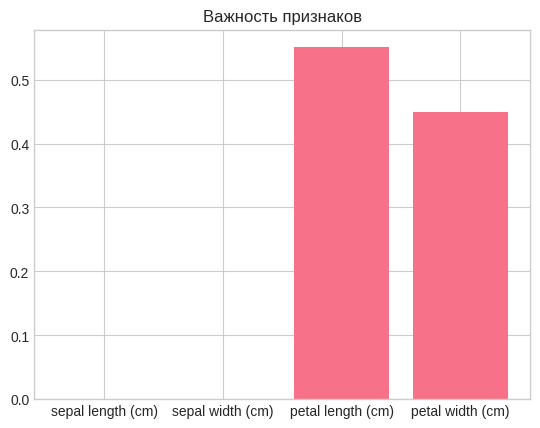

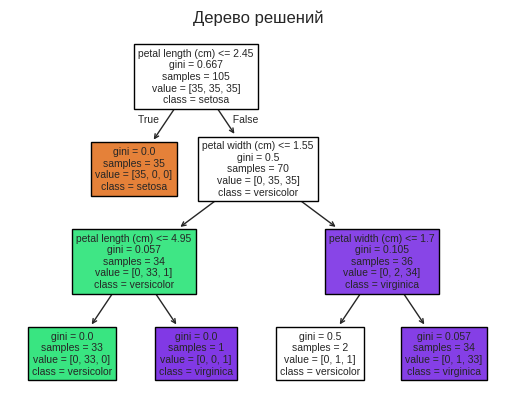

In [ ]:
print("Логистическая регрессия: accuracy =", accuracy_score(y_test, y_pred_log), "f1 =", f1_score(y_test, y_pred_log, average='weighted'))
print("SVM: accuracy =", accuracy_score(y_test, y_pred_svm), "f1 =", f1_score(y_test, y_pred_svm, average='weighted'))
print("Дерево решений: accuracy =", accuracy_score(y_test, y_pred_tree), "f1 =", f1_score(y_test, y_pred_tree, average='weighted'))

print("\nВажность признаков в дереве:")
print(iris.feature_names)
print(tree_model.feature_importances_)

print("\nПравила дерева:")
print(export_text(tree_model, feature_names=list(iris.feature_names)))

plt.bar(iris.feature_names, tree_model.feature_importances_)
plt.title("Важность признаков")
plt.show()

plot_tree(tree_model, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.title("Дерево решений")
plt.show()